In [7]:
# --- 1. SETUP AND DATA LOADING ---

# Import standard data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries for machine learning from Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Configure settings for all visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Load the same dataset we used in our EDA project
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
# --- 2. DATA PREPROCESSING FOR MACHINE LEARNING ---

# Models can only work with numerical data. We need to convert our categorical columns
# (sex, smoker, region) into numbers. The best way to do this is with One-Hot Encoding.

# One-Hot Encoding creates new binary (0 or 1) columns for each category.
# For example, the 'sex' column will be replaced by 'sex_female' and 'sex_male'.
# A row with 'female' will have 1 in 'sex_female' and 0 in 'sex_male'.

# Pandas has a convenient function for this: pd.get_dummies()
df_processed = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Let's see the result. Note the new columns at the end.
print("DataFrame after One-Hot Encoding:")
df_processed.head()

DataFrame after One-Hot Encoding:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [9]:
# --- 3. SPLITTING DATA INTO TRAINING AND TESTING SETS ---

# First, we need to define our features (X) and our target (y).
# X: The input variables our model will use to make predictions (everything except 'charges').
# y: The output variable we want to predict (the 'charges' column).

# Define X by dropping the target column
X = df_processed.drop('charges', axis=1)

# Define y as the target column
y = df_processed['charges']

# Now, we use the train_test_split function we imported from Scikit-learn
# This function shuffles the data and splits it into four pieces.
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

# Let's check the shapes of the new datasets to confirm the split
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1070, 8)
Shape of X_test: (268, 8)
Shape of y_train: (1070,)
Shape of y_test: (268,)


In [10]:
# --- 4. TRAINING THE LINEAR REGRESSION MODEL ---

# Step 1: Create an instance of the Linear Regression model
# We are creating an object based on the LinearRegression class we imported.
model = LinearRegression()

# Step 2: Train the model using the training data
# The .fit() method is the heart of the training process.
# The model will analyze X_train and y_train to learn the relationships between them.
model.fit(X_train, y_train)

# The model is now trained!
print("Model training complete.")

# (Optional) We can inspect the learned coefficients to see what the model thinks is important.
# A coefficient is the mathematical weight the model gives to each feature.
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nLearned Coefficients:")
print(coefficients)

Model training complete.

Learned Coefficients:
                   Coefficient
age                 256.975706
bmi                 337.092552
children            425.278784
sex_male            -18.591692
smoker_yes        23651.128856
region_northwest   -370.677326
region_southeast   -657.864297
region_southwest   -809.799354


In [11]:
# --- 5. MAKING PREDICTIONS ON THE TEST SET ---

# Now we use our trained model to make predictions on the unseen test data.
# The .predict() method takes the features of the test set (X_test) and returns the model's predictions.
y_pred = model.predict(X_test)

# Let's create a new DataFrame to compare the actual values with the predicted values.
# This makes it easy to see how well the model performed on individual examples.
predictions_df = pd.DataFrame({
    'Actual Charges': y_test, 
    'Predicted Charges': y_pred
})

# Display the first few rows of our comparison DataFrame
print("Comparison of Actual vs. Predicted Charges:")
predictions_df.head()

Comparison of Actual vs. Predicted Charges:


,Actual Charges,Predicted Charges
764,9095.06825,8969.550274
887,5272.17580,7068.747443
890,29330.98315,36858.410912
1293,9301.89355,9454.678501
259,33750.29180,26973.173457


Mean Absolute Error (MAE): $4,181.19
R-squared (R²): 0.78


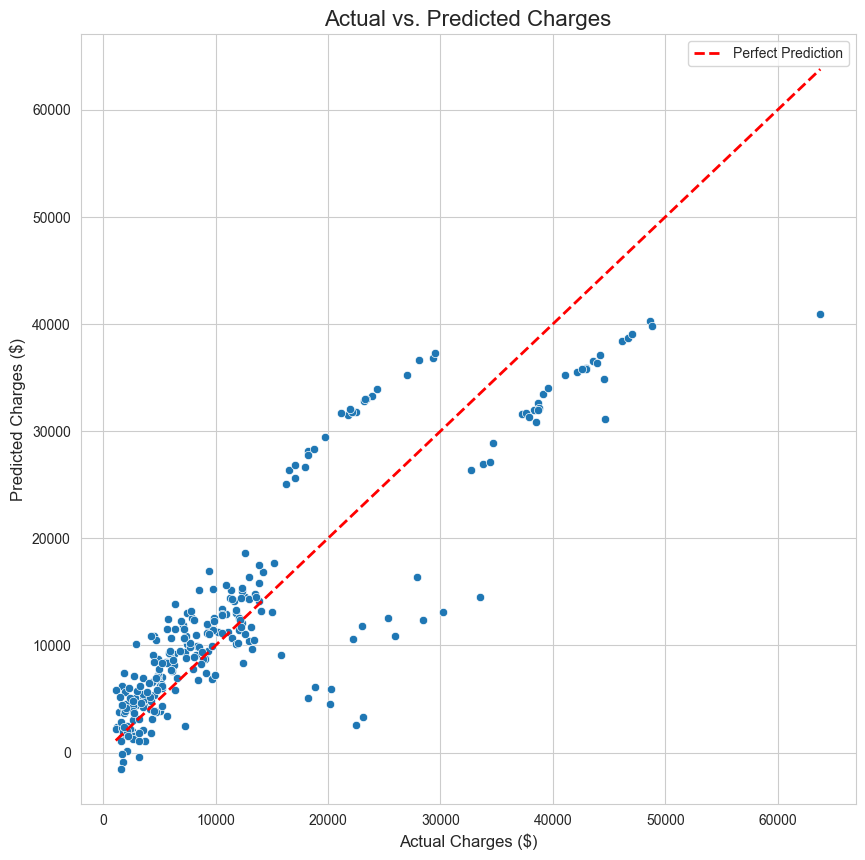

In [12]:
# --- 6. EVALUATING THE MODEL ---

# Now we'll use metrics to quantitatively measure the model's performance.

# --- Step 1: Calculate Performance Metrics ---

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")

# Calculate R-squared (R²)
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R²): {r2:.2f}")

# --- Step 2: Visualize the Predictions vs. Actual Values ---

# A scatter plot is a great way to visualize the performance of a regression model.
# If the model were perfect, all points would lie on a straight 45-degree line.
plt.figure(figsize=(10, 10))
sns.scatterplot(x=y_test, y=y_pred)

# Add a line representing a perfect prediction (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

# Add titles and labels
plt.title('Actual vs. Predicted Charges', fontsize=16)
plt.xlabel('Actual Charges ($)', fontsize=12)
plt.ylabel('Predicted Charges ($)', fontsize=12)
plt.legend()
plt.grid(True)

plt.savefig('images/actual_vs_predicted.png', bbox_inches='tight')

# Display the plot
plt.show()

# --- 7. Project Summary & Final Conclusions ---

This project aimed to build a machine learning model to predict individual medical insurance costs based on a patient's attributes. This serves as a natural extension of our previous exploratory data analysis.

### Summary of the Process:

1.  **Data Preprocessing**: We began by transforming the raw data into a format suitable for machine learning. This involved using **One-Hot Encoding** to convert categorical variables (`sex`, `smoker`, `region`) into a numerical representation.

2.  **Data Splitting**: The dataset was split into a **training set (80%)** and a **testing set (20%)**. The model was trained exclusively on the training data and evaluated on the unseen testing data to ensure an unbiased assessment of its performance.

3.  **Model Training**: A **Linear Regression** model from the Scikit-learn library was chosen for this task. The model was trained using the `.fit()` method on the training data.

4.  **Prediction & Evaluation**: The trained model was used to make predictions on the test set. Its performance was then evaluated using two key regression metrics.

### Model Performance:

*   **R-squared (R²)**: Our model achieved an R² score of approximately **0.78**. This means that our model is able to explain about **78% of the variability** in medical charges. This is a strong result for a simple linear model, indicating that the features we used (age, BMI, smoking status, etc.) are highly predictive of the final cost.

*   **Mean Absolute Error (MAE)**: The MAE was approximately **$4,181**. This metric tells us that, on average, our model's predictions are off by about $4,181. While this seems high, it should be considered in the context of the wide range of medical charges (which can exceed $60,000) and the high standard deviation in the data.

### Final Conclusion:

We successfully built a linear regression model that can predict medical insurance costs with a good degree of accuracy (R² of 0.78). The analysis confirms that a person's age, BMI, and, most importantly, smoking status are powerful predictors of their healthcare expenses.

While the model provides a solid baseline, the MAE indicates that there is still room for improvement. More advanced regression models (like Gradient Boosting or Random Forest) could potentially capture more complex patterns in the data and reduce the prediction error.

---
Thank you for reviewing this machine learning project!